In [1]:
# 使用可用的公开图像URL
image_urls = [
    "https://images.unsplash.com/photo-1506905925346-21bda4d32df4",  # 咖啡店场景
    "https://fastly.picsum.photos/id/1000/800/600.jpg?hmac=Mix9m7H2JSmfparTPNW4VIvJd9shkZakGjY8_Gcp7gQ"
    "https://images.unsplash.com/photo-1556740738-b6a63e27c4df"   # 办公室场景
]
# https://fastly.picsum.photos/id/1000/800/600

image_urls = [
    "https://images.unsplash.com/photo-1506905925346-21bda4d32df4",  # 咖啡店场景
    "https://images.unsplash.com/photo-1581091226825-a6a63e27c4df",  # 厨房场景
    "https://images.unsplash.com/photo-1556740738-b6a63e27c4df"   # 办公室场景
]

In [2]:
import os, requests, glob
import cv2
import numpy as np
from PIL import Image
from io import BytesIO
from ultralytics import YOLO
import matplotlib.pyplot as plt
import torch

# ---------- 配置 ----------
image_urls = [
    "https://images.unsplash.com/photo-1506905925346-21bda4d32df4",   # 咖啡店
    "https://images.unsplash.com/photo-1556740738-b6a63e27c4df",      # 办公室
]

save_dir = "./images"           # 本地保存目录
os.makedirs(save_dir, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
yolo_model = YOLO("yolov8n.pt").to(device)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"设备: {torch.cuda.get_device_name()}")

# ---------- 工具：把 URL 存到本地 ----------
def download_to_local(url: str, save_path: str) -> bool:
    try:
        r = requests.get(url, timeout=15)
        r.raise_for_status()
        with open(save_path, "wb") as f:
            f.write(r.content)
        return True
    except Exception as e:
        print(f"下载失败 {url}: {e}")
        return False

# ---------- 工具：从本地文件读入 ----------
# def load_image_from_local(path: str):
#     img = Image.open(path).convert("RGB")
#     return np.array(img)
def load_image_from_local(path: str, max_size=1280):
    img = Image.open(path).convert("RGB")
    w, h = img.size
    if max(w, h) > max_size:
        scale = max_size / max(w, h)
        img = img.resize((int(w * scale), int(h * scale)), Image.BILINEAR)
    return np.array(img)

print("\n=== 下载图片到本地（已有则跳过） ===")
local_paths = []
for i, url in enumerate(image_urls):
    fname = f"img_{i:02d}.jpg"
    path = os.path.join(save_dir, fname)

    # 已有就直接用
    if os.path.isfile(path):
        local_paths.append(path)
        print(f"已存在，跳过下载: {path}")
        continue

    # 不存在才请求下载
    if download_to_local(url, path):
        local_paths.append(path)
        print(f"已保存: {path}")
    else:
        print(f"跳过: {url}")

for path in local_paths:
    img = load_image_from_local(path)
    print(f"{os.path.basename(path)}: {img.shape}")


PyTorch: 2.11.0+cu126
CUDA可用: True
设备: NVIDIA GeForce RTX 4060 Laptop GPU

=== 下载图片到本地（已有则跳过） ===
已存在，跳过下载: ./images/img_00.jpg
已存在，跳过下载: ./images/img_01.jpg
img_00.jpg: (853, 1280, 3)
img_01.jpg: (853, 1280, 3)


In [21]:
for path in local_paths:
    img = load_image_from_local(path)
    print(f"{os.path.basename(path)}: {img.shape}")

img_00.jpg: (853, 1280, 3)
img_01.jpg: (853, 1280, 3)


GPU 热身中（请忽略这步的耗时）...
热身完成！


=== YOLO检测（读本地文件） ===
img_00.jpg: 检测到 0 个目标, 耗时 50.2ms
img_01.jpg: 检测到 9 个目标, 耗时 20.4ms


/home/chendawww/Software/anaconda3/envs/ros2/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chendawww/Software/anaconda3/envs/ros2/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


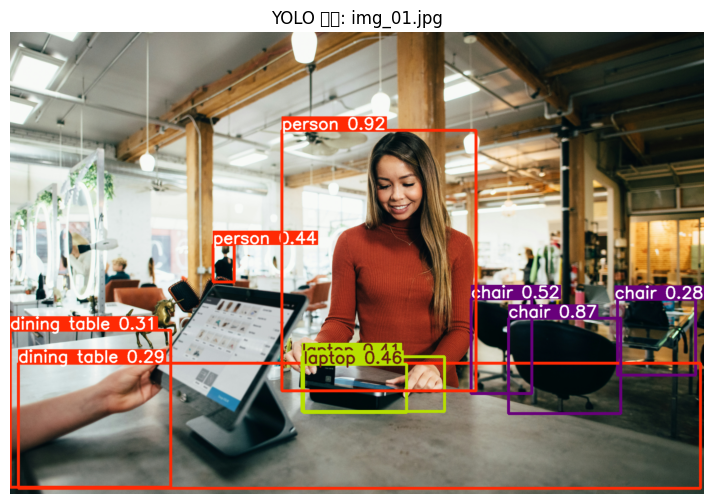

In [3]:
import time

# ---------- 检测函数（尽量干净） ----------
def detect_with_yolo_local(image_np):
    if image_np is None:
        return None, None
    t0 = time.perf_counter()
    results = yolo_model(image_np, verbose=False)
    t1 = time.perf_counter()
    infer_ms = (t1 - t0) * 1000
    boxes = results[0].boxes if len(results) > 0 else None
    annotated = results[0].plot() if len(results) > 0 else image_np.copy()
    t1 = time.perf_counter()
    return annotated, boxes, infer_ms

# ---------- GPU 热身（解决冷启动慢的问题） ----------
print("GPU 热身中（请忽略这步的耗时）...")
dummy_img = np.zeros((640, 640, 3), dtype=np.uint8)
for _ in range(3):
    _ = yolo_model(dummy_img, verbose=False)
print("热身完成！\n")

# ---------- 主流程 ----------
print("\n=== YOLO检测（读本地文件） ===")
for path in local_paths:
    img_np = load_image_from_local(path)
    annotated, boxes, infer_ms = detect_with_yolo_local(img_np)

    n = len(boxes) if (boxes is not None) else 0
    print(f"{os.path.basename(path)}: 检测到 {n} 个目标, 耗时 {infer_ms:.1f}ms")

    # 只画第一张有结果的（减少 Jupyter 阻塞）
    if n > 0:
        plt.figure(figsize=(10, 6))
        plt.imshow(annotated)
        plt.title(f"YOLO 结果: {os.path.basename(path)}")
        plt.axis("off")
        plt.show()
        break  # 只看第一张就好

# 如果想批量保存结果图而不是 plt.show，可以取消下面注释：
# out_dir = "./images_output"
# os.makedirs(out_dir, exist_ok=True)
# for path in local_paths:
#     img_np = load_image_from_local(path)
#     annotated, _ = detect_with_yolo_local(img_np)
#     out_path = os.path.join(out_dir, os.path.basename(path))
#     cv2.imwrite(out_path, cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR))
# print("结果图已保存到:", out_dir)


Grounding DINO 检测（优化版）
使用设备: cuda
加载 Grounding DINO 模型...
final text_encoder_type: /home/chendawww/workspace/hf/bert-base-uncased


Some weights of the model checkpoint at /home/chendawww/workspace/hf/bert-base-uncased were not used when initializing BertModel: ['cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.decoder.weight', 'cls.predictions.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


模型加载完成

预热中（仅第一次慢）...


/tmp/ipykernel_791202/420030924.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


预热完成，耗时 0.76s



/tmp/ipykernel_791202/420030924.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  img_00.jpg: 0 个目标 | 0.633s
  img_01.jpg: 1 个目标 | 1.258s
    - bag (0.39)


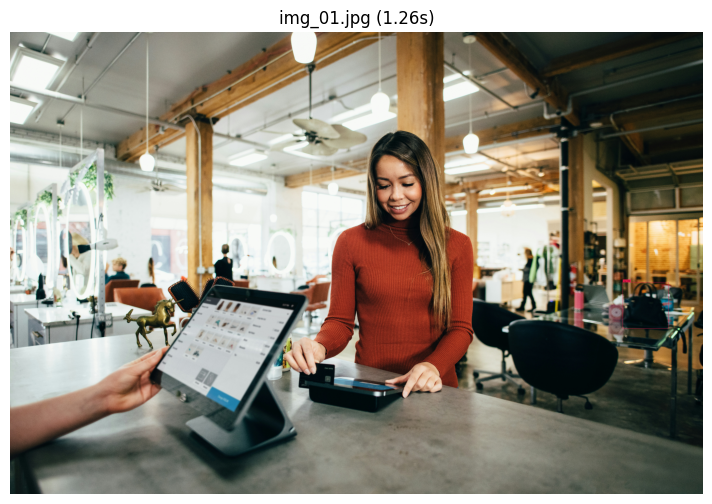


共处理 2 张，总耗时 3.53s，平均 1.76s/张
全部完成！


In [19]:
print("=" * 50)
print("Grounding DINO 检测（优化版）")
print("=" * 50)

import os
import time
import torch
import cv2
import matplotlib.pyplot as plt

os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
torch.backends.cudnn.benchmark = True

from groundingdino.util.inference import load_model, predict, annotate as gd_annotate, load_image

# ---------- 配置 ----------
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"使用设备: {device}")

GD_CONFIG = "/home/chendawww/workspace/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py"
GD_CHECKPOINT = "/home/chendawww/workspace/GroundingDINO/weights/groundingdino_swint_ogc.pth"

TEXT_PROMPT = "bag ."
BOX_THRESHOLD = 0.35
TEXT_THRESHOLD = 0.25

IMG_PATH = "/home/chendawww/workspace/rl-navibot/app/harness/test/images"
local_paths = ["./images/img_00.jpg", "./images/img_01.jpg"]  # ← 替换为你的实际路径

# ---------- 加载模型 ----------
print("加载 Grounding DINO 模型...")
gd_model = load_model(GD_CONFIG, GD_CHECKPOINT, device=device)
gd_model.eval()
print("模型加载完成\n")

# ---------- 预热 ----------
print("预热中（仅第一次慢）...")
_warmup_tensor = load_image(local_paths[0])[1]  # 只取 tensor，不要 tuple

_t0 = time.time()
with torch.no_grad():
    if device == "cuda":
        with torch.cuda.amp.autocast():
            predict(
                model=gd_model, image=_warmup_tensor,
                caption=TEXT_PROMPT, box_threshold=BOX_THRESHOLD,
                text_threshold=TEXT_THRESHOLD, device=device,
            )
    else:
        predict(
            model=gd_model, image=_warmup_tensor,
            caption=TEXT_PROMPT, box_threshold=BOX_THRESHOLD,
            text_threshold=TEXT_THRESHOLD, device=device,
        )
del _warmup_tensor
torch.cuda.empty_cache()
print(f"预热完成，耗时 {time.time() - _t0:.2f}s\n")


# ---------- 推理函数 ----------
def detect_grounding_dino(image_path):
    t0 = time.time()
    image_source, image_tensor = load_image(image_path)

    if device == "cuda":
        with torch.cuda.amp.autocast():
            boxes, logits, phrases = predict(
                model=gd_model, image=image_tensor,
                caption=TEXT_PROMPT, box_threshold=BOX_THRESHOLD,
                text_threshold=TEXT_THRESHOLD, device=device,
            )
    else:
        boxes, logits, phrases = predict(
            model=gd_model, image=image_tensor,
            caption=TEXT_PROMPT, box_threshold=BOX_THRESHOLD,
            text_threshold=TEXT_THRESHOLD, device=device,
        )

    annotated_frame = gd_annotate(
        image_source=image_source, boxes=boxes,
        logits=logits, phrases=phrases,
    )
    elapsed = time.time() - t0
    return annotated_frame, boxes, logits, phrases, elapsed


# ---------- 批量检测 ----------
total_start = time.time()
count = 0

for path in local_paths:
    if not os.path.exists(path):
        print(f"  [跳过] 文件不存在: {path}")
        continue

    count += 1
    annotated_frame, boxes, logits, phrases, elapsed = detect_grounding_dino(path)

    n = len(boxes) if boxes is not None else 0
    print(f"  {os.path.basename(path)}: {n} 个目标 | {elapsed:.3f}s")

    if n > 0:
        for phrase, score in zip(phrases, logits):
            print(f"    - {phrase.strip('. ')} ({score:.2f})")
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
        plt.title(f"{os.path.basename(path)} ({elapsed:.2f}s)")
        plt.axis("off")
        plt.show()

total_time = time.time() - total_start
if count > 0:
    print(f"\n共处理 {count} 张，总耗时 {total_time:.2f}s，平均 {total_time/count:.2f}s/张")
print("全部完成！")


In [20]:
for path in local_paths:
    h, w = cv2.imread(path).shape[:2]
    print(f"  {os.path.basename(path)}: {w}x{h}")


  img_00.jpg: 4878x3252
  img_01.jpg: 8140x5427
